# Analyze E02 — no-OHO + wd-sweep
Existential ablation: does fixed-wd training (no OHO at all) match OHO winners from e01_sos?

**Setup:** 6 wd values × 5 seeds = 30 cells. β fixed at 1.0, inner_lr fixed at 0.1, no outer optimizer. Same SOS base task as e01_sos so arch/data/eval are directly comparable.

**Decision rule (set ahead of time):**
- best fixed-wd loss ≤ 2.0 → OHO is decoration
- best fixed-wd loss 2.0–5.0 → OHO helps but mostly wd matters
- best fixed-wd loss ≥ 5.0 → OHO is essential

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import re
from clearml import Task
from clearml.backend_api.session.client import APIClient

HPO_ID = "b02bbd548c6a4498b750df9c99006119"
LOG_DIR = Path("/scratch/wlp9800/offline_logs")
CACHE_PATH = Path("/tmp/e02_wd_df.parquet")

# All 3 region levels: 0=train (hole-excluded), 1=val (only the hole — OOD), 2=test (full)
METRIC_PATHS = {}
for lvl in [0, 1, 2]:
    METRIC_PATHS[f"loss_l{lvl}"]       = f"eval_accumulated/level{lvl}/loss/0/0/0"
    METRIC_PATHS[f"mig_l{lvl}"]        = f"disentanglement/level{lvl}/mig"
    METRIC_PATHS[f"modularity_l{lvl}"] = f"disentanglement/level{lvl}/modularity"
    METRIC_PATHS[f"tc_l{lvl}"]         = f"disentanglement/level{lvl}/tc"

ABORT_PATH = "train/level0/loss/0/0/0"
FACTOR_PATHS = {
    "wd":   "config/hyperparameters/meta1_sgd1_wd/value",
    "seed": "config/seed/global_seed",
}

# e01_sos OHO winners for reference (read on demand)
OHO_WINNERS = {
    "20849b4 (additive_adam mlr=1e-5 meta2β=0)":   "20849b4381ca4e41973dea94e1dd7f2f",
    "2c87f135 (mlr=1e-5 meta2β=0 b1=0.99)":         "2c87f135f6764728a6dc388479dcf3a0",
    "4890067355 (mlr=1e-4 meta2β=1)":               "4890067355fd486094a31bc33497d505",
    "923407ff (mlr=1e-4 meta2β=1 b1=0.99)":         "923407ff64b947bd86713c6ec48cb6d1",
}

## 1. Build per-cell DataFrame

In [2]:
def find_h5(task_id):
    matches = sorted(LOG_DIR.glob(f"metrics_{task_id}*.h5"))
    return matches[-1] if matches else None

def final_value(f, path):
    if path not in f or f"{path}_iterations" not in f: return None
    v = f[path][:]; it = f[f"{path}_iterations"][:]
    m = (it>=0) & np.isfinite(v); v = v[m]
    return float(v[-1]) if len(v) else None

def detect_abort(f):
    if ABORT_PATH not in f: return False
    it = f[f"{ABORT_PATH}_iterations"][:]
    if not (it>=0).any(): return True
    return int(it[it>=0].max()) < 1000

def build_df():
    if CACHE_PATH.exists():
        print(f"loading cached DataFrame from {CACHE_PATH}")
        return pd.read_parquet(CACHE_PATH)
    c = APIClient()
    api_tasks = c.tasks.get_all(parent=HPO_ID, page_size=500, only_fields=["id","status"])
    print(f"found {len(api_tasks)} child tasks")
    rows = []
    for at in api_tasks:
        t = Task.get_task(task_id=at.id)
        params = t.get_parameters()
        h5 = find_h5(at.id)
        row = {"task_id": at.id, "status": str(at.status)}
        for k, p in FACTOR_PATHS.items():
            try: row[k] = float(params.get(p))
            except: row[k] = None
        if h5 is None:
            for m in METRIC_PATHS: row[m] = np.nan
            row["aborted"] = True
        else:
            with h5py.File(h5,"r") as f:
                for m, p in METRIC_PATHS.items():
                    row[m] = final_value(f, p)
                row["aborted"] = detect_abort(f)
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_parquet(CACHE_PATH)
    return df

df = build_df()
df_ok = df[~df["aborted"]].copy()
print(f"\n{len(df)} cells total, {df['aborted'].sum()} aborted, {len(df_ok)} usable")
print(f"wd values: {sorted(df_ok['wd'].unique())}")
print(f"seeds: {sorted(df_ok['seed'].unique())}")

loading cached DataFrame from /tmp/e02_wd_df.parquet

30 cells total, 0 aborted, 30 usable
wd values: [np.float64(1e-06), np.float64(1e-05), np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.1)]
seeds: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


## 2. OHO winner reference points
Pull all-3-level metrics for the e01_sos winners so we can plot OHO vs no-OHO side-by-side.

In [3]:
def collect_metrics(tid):
    h5 = find_h5(tid)
    if h5 is None: return None
    out = {}
    with h5py.File(h5,"r") as f:
        for m, p in METRIC_PATHS.items():
            out[m] = final_value(f, p)
    return out

oho_ref = pd.DataFrame([{**{"label":lbl, "task_id":tid}, **(collect_metrics(tid) or {})} for lbl, tid in OHO_WINNERS.items()])
print(oho_ref[['label','loss_l0','loss_l1','loss_l2','mig_l0','mig_l1','mig_l2']].to_string(index=False))

                                    label  loss_l0  loss_l1  loss_l2   mig_l0   mig_l1   mig_l2
20849b4 (additive_adam mlr=1e-5 meta2β=0) 0.951172 2.085901 1.327750 0.746793 0.790169 0.771770
     2c87f135 (mlr=1e-5 meta2β=0 b1=0.99) 0.794729 2.284063 1.281670 0.771109 0.781000 0.786172
           4890067355 (mlr=1e-4 meta2β=1) 0.523467 1.171496 0.736668 0.776779 0.800642 0.814300
     923407ff (mlr=1e-4 meta2β=1 b1=0.99) 0.976374 2.105941 1.345848 0.800884 0.800237 0.832273


## 3. Loss distribution per wd, all 3 levels
Boxplots with horizontal lines showing OHO winner reference points. Level 1 (OOD hole) is the headline metric.

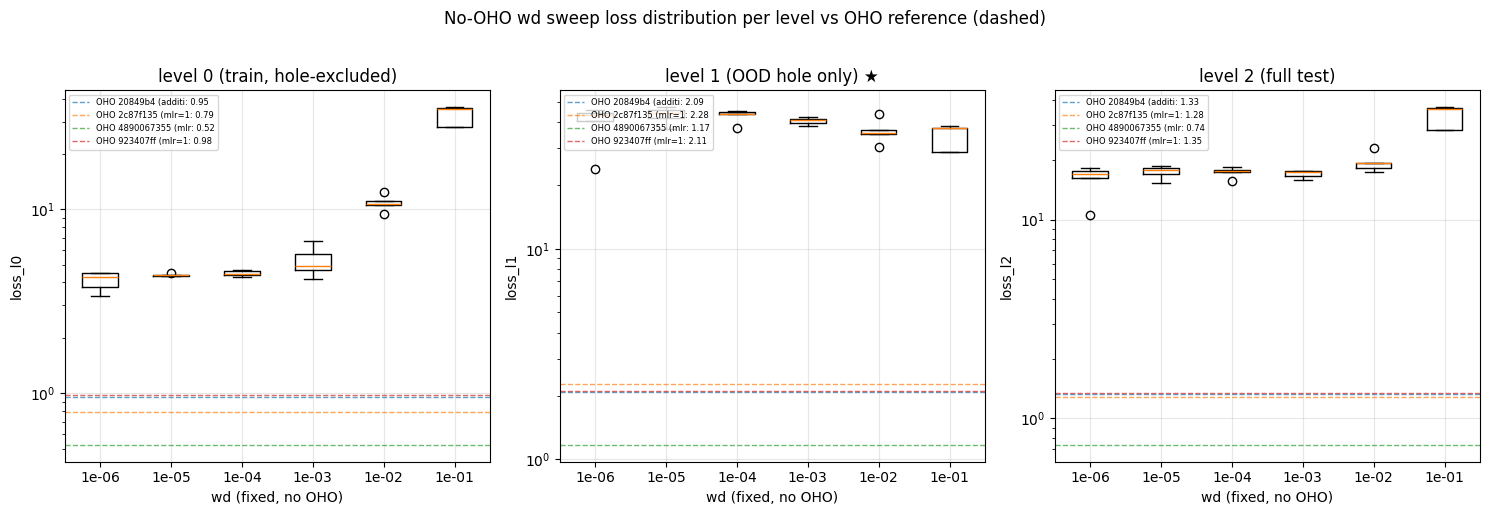

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
wd_vals = sorted(df_ok['wd'].unique())
labels = [f"{w:.0e}" for w in wd_vals]

level_titles = {"loss_l0":"level 0 (train, hole-excluded)",
                "loss_l1":"level 1 (OOD hole only) ★",
                "loss_l2":"level 2 (full test)"}

for ax, metric_col in zip(axes, ["loss_l0","loss_l1","loss_l2"]):
    data = [df_ok[df_ok['wd']==w][metric_col].dropna().values for w in wd_vals]
    ax.boxplot(data, tick_labels=labels, showfliers=True)
    ax.set_yscale('log')
    ax.set_xlabel("wd (fixed, no OHO)")
    ax.set_ylabel(metric_col)
    ax.set_title(level_titles[metric_col])
    ax.grid(True, alpha=0.3)
    cmap = plt.get_cmap("tab10")
    for i, (lbl, row) in enumerate(oho_ref.iterrows()):
        v = row[metric_col]
        if pd.notna(v):
            ax.axhline(v, color=cmap(i), linestyle='--', linewidth=1, alpha=0.7,
                       label=f"OHO {row['label'][:15]}: {v:.2f}")
    ax.legend(loc='upper left', fontsize=6)
fig.suptitle("No-OHO wd sweep loss distribution per level vs OHO reference (dashed)", y=1.02)
plt.tight_layout(); plt.show()

## 4. MIG distribution per wd, all 3 levels

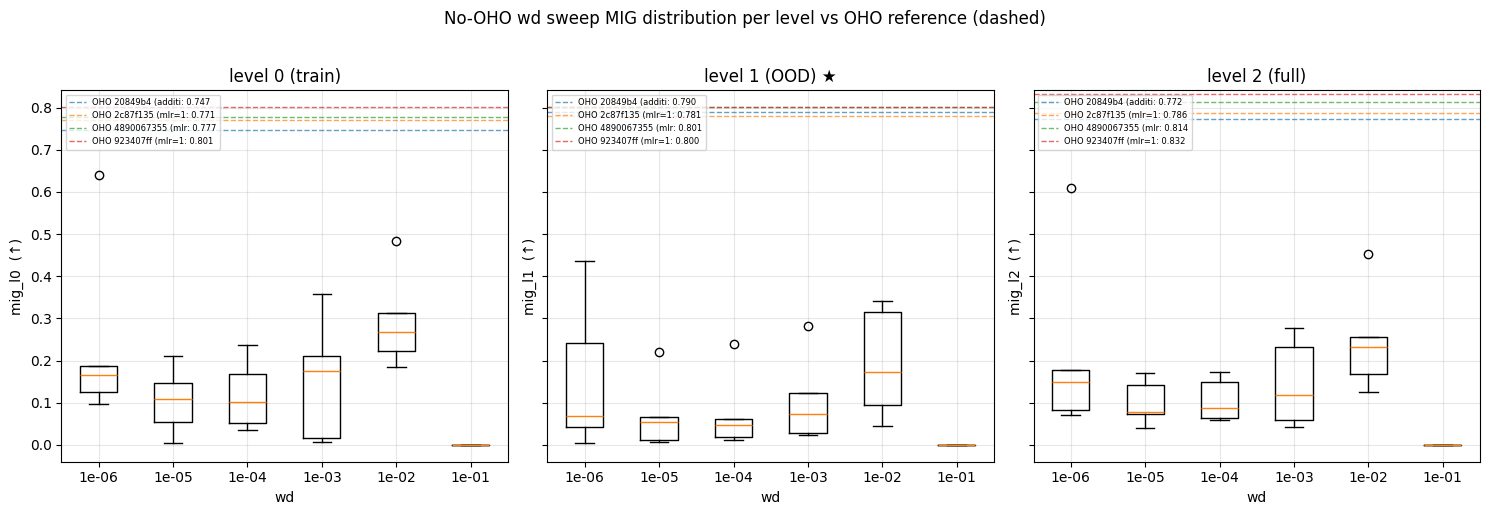

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, metric_col, title in zip(axes,
                                  ["mig_l0","mig_l1","mig_l2"],
                                  ["level 0 (train)","level 1 (OOD) ★","level 2 (full)"]):
    data = [df_ok[df_ok['wd']==w][metric_col].dropna().values for w in wd_vals]
    ax.boxplot(data, tick_labels=labels, showfliers=True)
    ax.set_xlabel("wd")
    ax.set_ylabel(metric_col + "  (↑)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    cmap = plt.get_cmap("tab10")
    for i, (_, row) in enumerate(oho_ref.iterrows()):
        v = row[metric_col]
        if pd.notna(v):
            ax.axhline(v, color=cmap(i), linestyle='--', linewidth=1, alpha=0.7,
                       label=f"OHO {row['label'][:15]}: {v:.3f}")
    ax.legend(loc='upper left', fontsize=6)
fig.suptitle("No-OHO wd sweep MIG distribution per level vs OHO reference (dashed)", y=1.02)
plt.tight_layout(); plt.show()

## 5. Train → OOD generalization gap
Ratio loss_l1 / loss_l0 — how much worse does the model do on the held-out region than on training? Smaller is better.

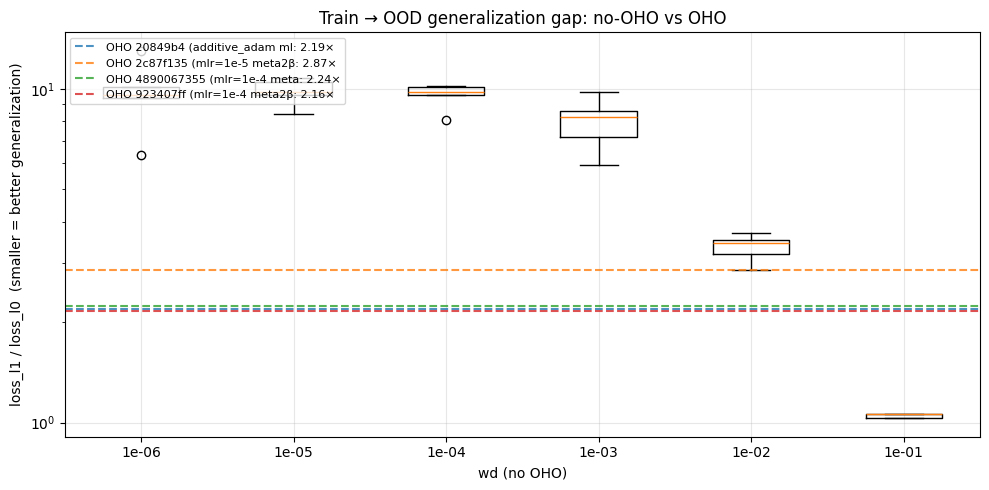

In [6]:
df_ok['gap_ratio'] = df_ok['loss_l1'] / df_ok['loss_l0']
oho_ref['gap_ratio'] = oho_ref['loss_l1'] / oho_ref['loss_l0']

fig, ax = plt.subplots(figsize=(10, 5))
data = [df_ok[df_ok['wd']==w]['gap_ratio'].dropna().values for w in wd_vals]
ax.boxplot(data, tick_labels=labels)
ax.set_yscale('log')
ax.set_xlabel("wd (no OHO)")
ax.set_ylabel("loss_l1 / loss_l0  (smaller = better generalization)")
ax.set_title("Train → OOD generalization gap: no-OHO vs OHO")
ax.grid(True, alpha=0.3)
cmap = plt.get_cmap("tab10")
for i, (_, row) in enumerate(oho_ref.iterrows()):
    ax.axhline(row['gap_ratio'], color=cmap(i), linestyle='--', linewidth=1.5, alpha=0.8,
               label=f"OHO {row['label'][:25]}: {row['gap_ratio']:.2f}×")
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## 6. Decision-rule summary table

In [7]:
summary = []
for wd_val, grp in df_ok.groupby('wd'):
    summary.append({
        "wd":          wd_val,
        "n_seeds":     len(grp),
        "loss_l1_min": grp['loss_l1'].min(),
        "loss_l1_mean":grp['loss_l1'].mean(),
        "loss_l1_std": grp['loss_l1'].std(),
        "mig_l1_max":  grp['mig_l1'].max(),
        "mig_l1_mean": grp['mig_l1'].mean(),
    })
summary_df = pd.DataFrame(summary).round(3)
print("=== no-OHO results, by wd ===")
print(summary_df.to_string(index=False))

best_loss_l1_noho = df_ok['loss_l1'].min()
best_loss_l1_oho  = oho_ref['loss_l1'].min()
ratio = best_loss_l1_noho / best_loss_l1_oho
print(f"\n=== headline numbers ===")
print(f"Best no-OHO OOD loss:  {best_loss_l1_noho:.3f}")
print(f"Best OHO OOD loss:     {best_loss_l1_oho:.3f}")
print(f"Multiplicative gap:    {ratio:.1f}× — OHO is {ratio:.1f}x better on OOD")
print(f"\nDecision rule: loss_l1 >= 5.0 in no-OHO sweep → OHO is essential. Actual: {best_loss_l1_noho:.1f}")

=== no-OHO results, by wd ===
   wd  n_seeds  loss_l1_min  loss_l1_mean  loss_l1_std  mig_l1_max  mig_l1_mean
0.000        5       23.945        39.416        8.857       0.436        0.159
0.000        5       37.089        43.146        3.903       0.220        0.072
0.000        5       37.604        42.943        3.060       0.239        0.076
0.001        5       38.287        40.531        1.628       0.282        0.106
0.010        5       30.439        36.257        4.773       0.342        0.194
0.100        5       28.820        34.182        4.888       0.000        0.000

=== headline numbers ===
Best no-OHO OOD loss:  23.945
Best OHO OOD loss:     1.171
Multiplicative gap:    20.4× — OHO is 20.4x better on OOD

Decision rule: loss_l1 >= 5.0 in no-OHO sweep → OHO is essential. Actual: 23.9


## 7. Latent comparison: best no-OHO cell vs OHO winner
Visual confirmation that no-OHO produces worse / collapsed latents.

Best no-OHO cell (by OOD loss): 5509cf50 — wd=1e-06, seed=0
  loss_l1=23.94  mig_l1=0.436


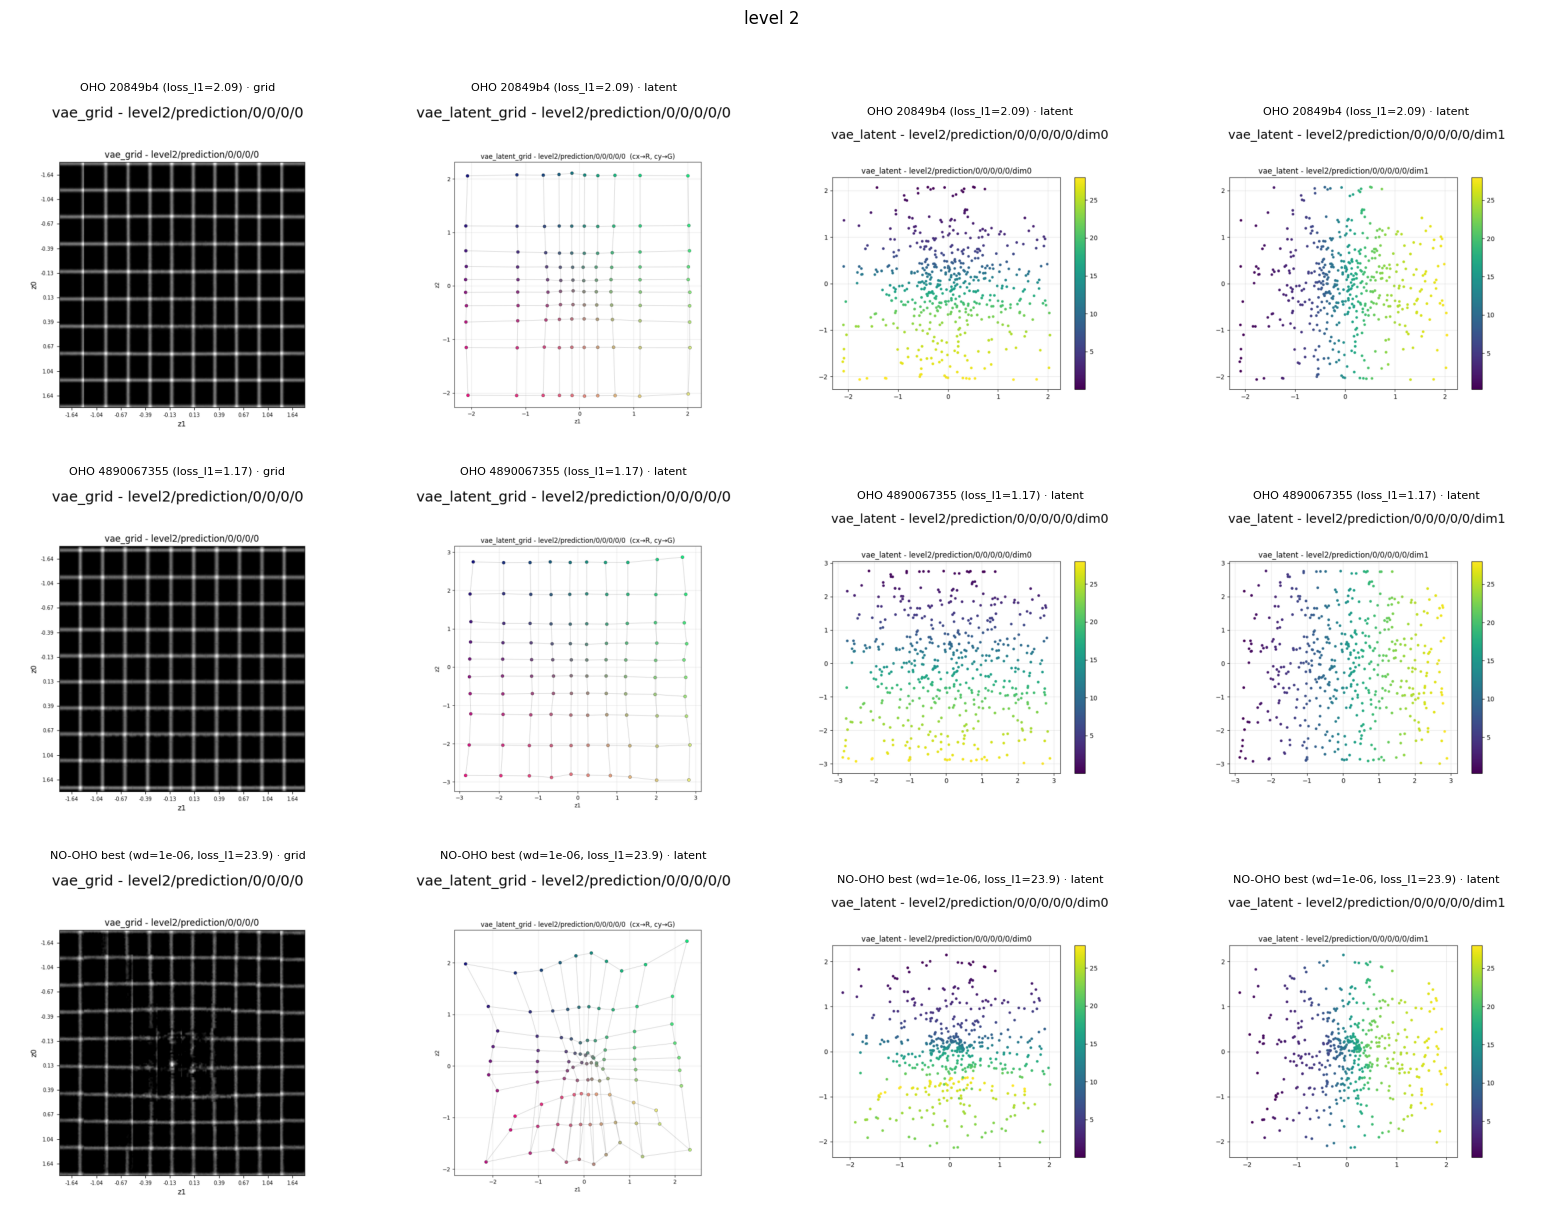

In [8]:
def final_image(task_id: str, series_key: str):
    d = LOG_DIR / f"images_{task_id}"
    if not d.exists(): return None
    best = None
    for p in d.glob(f"{series_key}_*.png"):
        m = re.match(rf"{re.escape(series_key)}_(\d+)\.png$", p.name)
        if m is None: continue
        it = int(m.group(1))
        if best is None or it > best[0]: best = (it, p)
    return best

def compare_latents(task_ids, titles, level=2):
    series = [
        f"vae_grid_level{level}_prediction_0_0_0_0",
        f"vae_latent_grid_level{level}_prediction_0_0_0_0_0",
        f"vae_latent_level{level}_prediction_0_0_0_0_0_dim0",
        f"vae_latent_level{level}_prediction_0_0_0_0_0_dim1",
    ]
    fig, axes = plt.subplots(len(task_ids), len(series), figsize=(4*len(series), 4*len(task_ids)))
    if len(task_ids) == 1: axes = axes[None,:]
    for ri, (tid, title) in enumerate(zip(task_ids, titles)):
        for ci, key in enumerate(series):
            ax = axes[ri, ci]
            r = final_image(tid, key)
            if r is None:
                ax.text(0.5, 0.5, "missing", ha="center", va="center"); ax.axis("off"); continue
            ax.imshow(np.asarray(Image.open(r[1])))
            ax.set_title(f"{title} · {key.split('_')[1]}", fontsize=8); ax.axis("off")
    fig.suptitle(f"level {level}", y=1.02); plt.tight_layout(); plt.show()

best_noho = df_ok.loc[df_ok['loss_l1'].idxmin()]
print(f"Best no-OHO cell (by OOD loss): {best_noho['task_id'][:8]} — wd={best_noho['wd']:g}, seed={int(best_noho['seed'])}")
print(f"  loss_l1={best_noho['loss_l1']:.2f}  mig_l1={best_noho['mig_l1']:.3f}")
compare_latents(
    ["20849b4381ca4e41973dea94e1dd7f2f",
     "4890067355fd486094a31bc33497d505",
     best_noho['task_id']],
    ["OHO 20849b4 (loss_l1=2.09)",
     "OHO 4890067355 (loss_l1=1.17)",
     f"NO-OHO best (wd={best_noho['wd']:g}, loss_l1={best_noho['loss_l1']:.1f})"],
    level=2,
)